In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
import h5py
from scipy.io import loadmat
import random
import pickle
import sys
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_63552\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_63552\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


In [3]:
check = J_pickle['J_all']
print(check.keys())

print(check['goCue'])


dict_keys(['interpPSTH', 'times', 'targetOn', 'goCue', 'moveStarts'])
[1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200 1200
 1200 1

In [4]:
check = N_pickle['N_all']
print(check.keys())

print(check['goCue'])

dict_keys(['interpPSTH', 'times', 'targetOn', 'goCue', 'moveStarts'])
[1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180 1180
 1180 1

index for ideal variance is  36


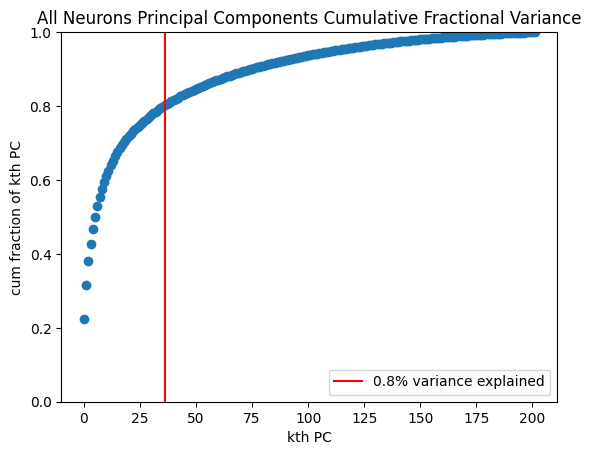

In [5]:
pcar.frac_var(J_all_PSTH_new, .8, True)

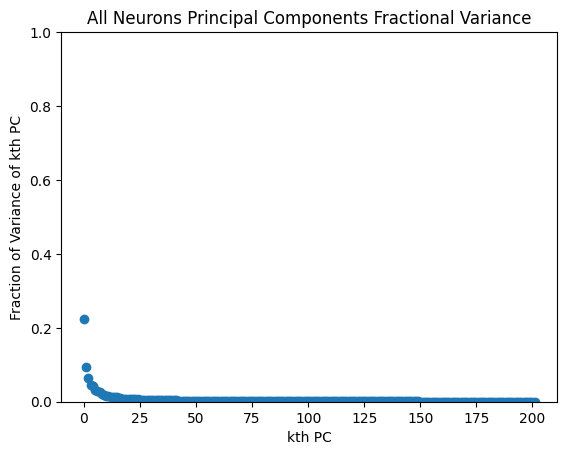

In [6]:
_, _, _ = pcar.svd(J_all_PSTH_new, True)

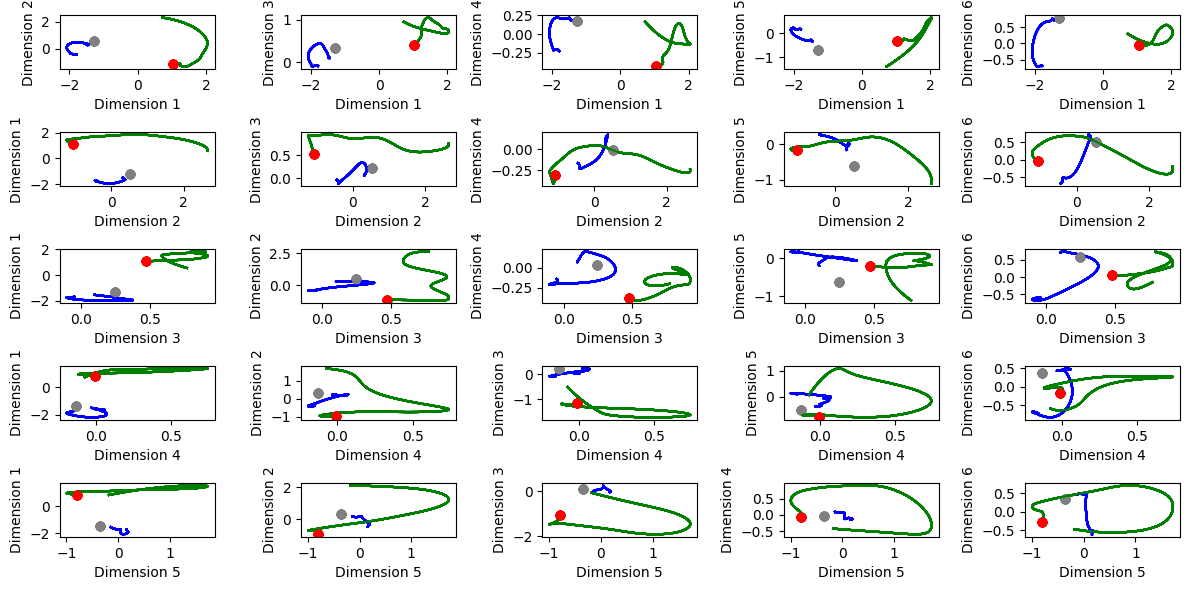

In [3]:
pcar.fig_3_cut_t(N_all_tensor, 6)

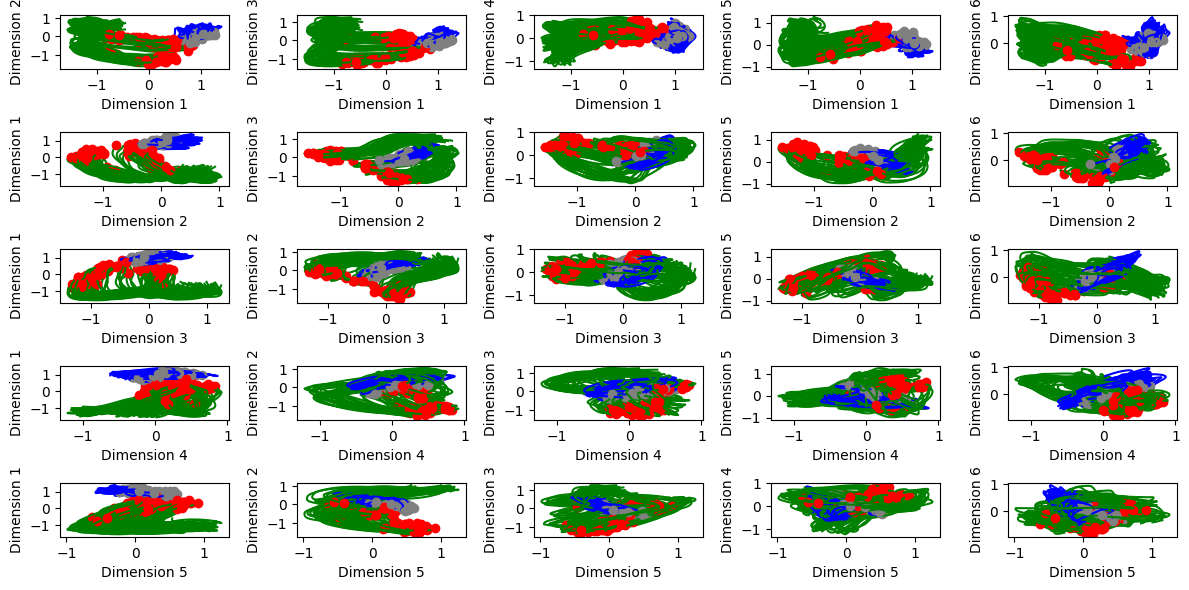

In [4]:
pcar.fig_3_cut_t(J_all_tensor, 6)

(108, 6, 118)
(6, 118)
(118,)
(118,)


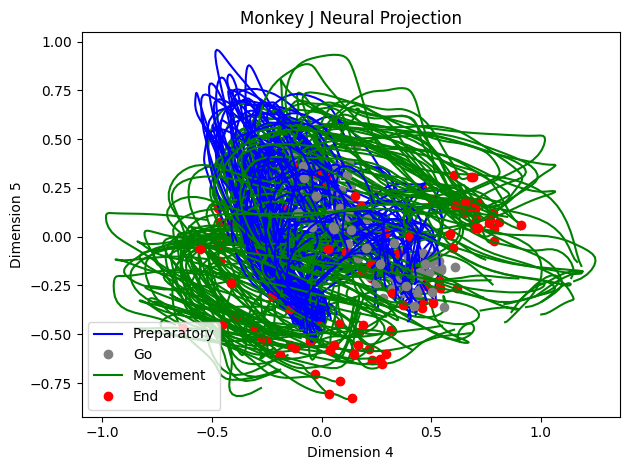

In [3]:
pcar.fig_3_spec(J_all_tensor, 6, d1 = 4, d2 = 5)

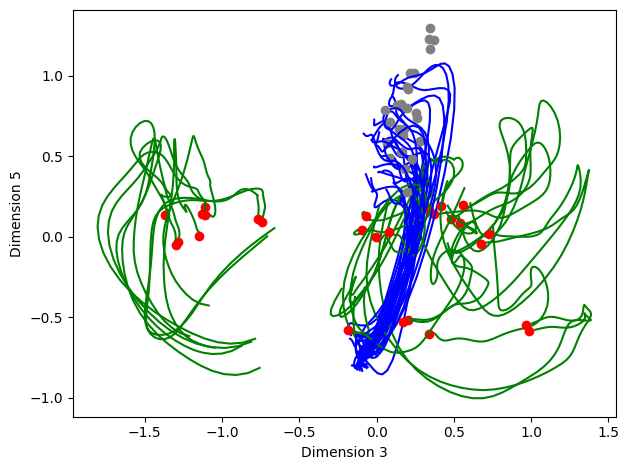

In [9]:
pcar.fig_3_spec(N_all_tensor, 6, d1 = 3, d2 = 5)

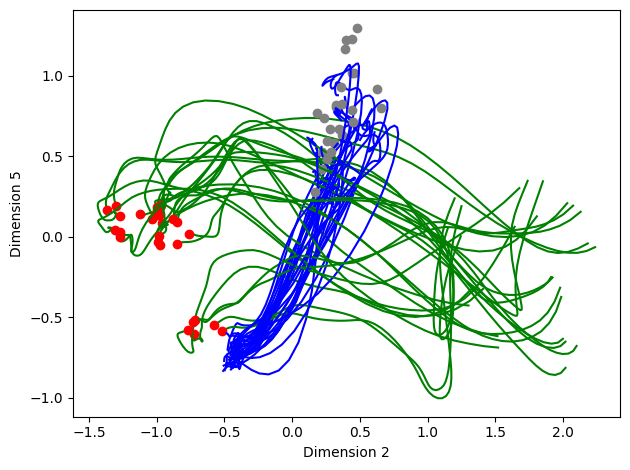

In [10]:
pcar.fig_3_spec(N_all_tensor, 6, d1 = 2, d2 = 5)

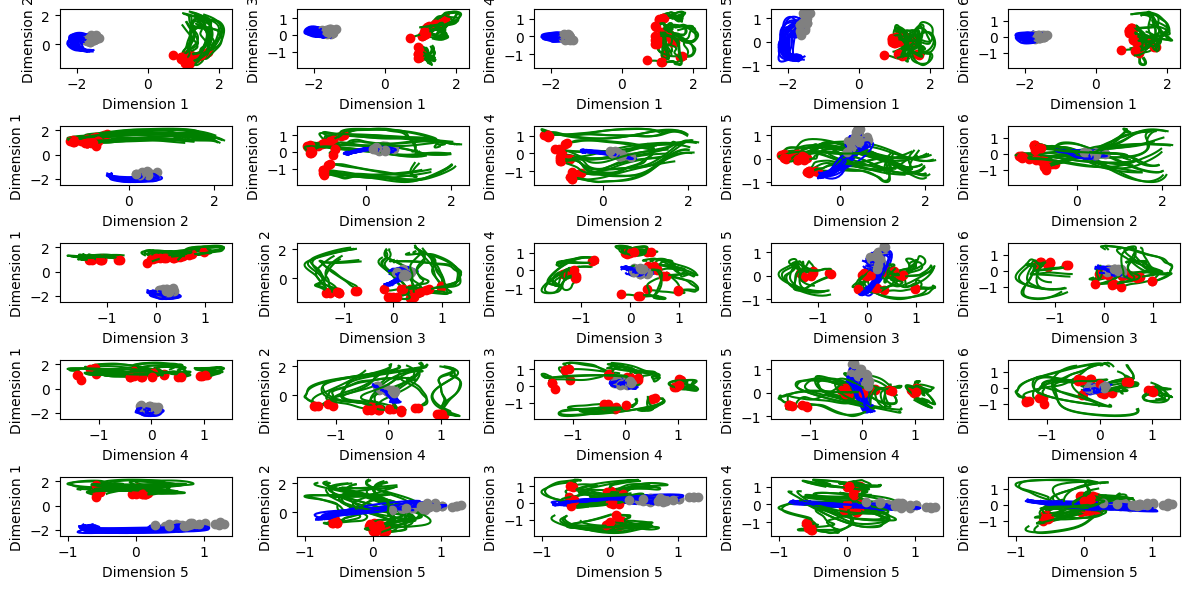

In [4]:
pcar.fig_3_cut_t(N_all_tensor, 6)